In [ ]:
"""
Docstring for derived_features.ipynb

Computes the following derived features from the
base KOI dataset.
    - Semi major axis `a`
    - Stellar mass m_*|

    
Author: Esraaj Sarkar Gupta
"""
None

In [2]:
# ---- Imports ---- #
import numpy as np
import pandas as pd

from pathlib import Path

# ---- Conversion Metrics ---- #

# --- Physical Constants (SI Units) --- #
G_CONST = 6.6743e-11      # Gravitational constant in m^3 / (kg * s^2)
R_SUN = 6.957e8           # Radius of the Sun in meters
M_SUN = 1.9884e30         # Mass of the Sun in kilograms
AU_UNIT = 1.496e11        # Meters to Astronomical Units

# --- Conversion Functions ---
def slogg_to_si(slogg: float) -> float:
    """
    Converts log10(gravity) in cgs units (cm/s^2) to SI units (m/s^2).
    """
    g_cgs = 10 ** slogg       # Convert log10 back to linear cm/s^2
    g_si = g_cgs * 0.01       # Convert cm/s^2 to m/s^2
    return g_si

def srad_to_si(srad: float) -> float:
    """
    Converts stellar radius from Solar Radii to meters.
    """
    return srad * R_SUN

# --- Conversion Function ---
def period_to_si(period_days: float) -> float:
    """
    Converts orbital period from days to seconds.
    """
    return period_days * 86400.0

In [3]:
# ---- Load Data ---- #
data_path : Path = Path("../data/processed/cleaned_non_standardized_train.csv")
data = pd.read_csv(data_path)

data.head()

,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,Target
0,5980783,CONFIRMED,37.303320,7.7930,551.7,19.5,2.31,493.0,14.00,5646.0,4.550,0.817,1.0
1,10212441,CONFIRMED,15.044710,5.8230,97.9,23.4,1.51,931.0,177.24,5798.0,4.025,1.525,1.0
2,8395660,CONFIRMED,43.844397,6.8020,615.2,83.7,2.87,531.0,18.77,5854.0,4.406,1.012,1.0
3,8478994,CONFIRMED,21.301819,3.8763,87.3,32.4,0.72,564.0,23.89,5437.0,4.571,0.781,1.0
4,4833421,CONFIRMED,37.996237,6.7751,403.7,37.8,2.39,618.0,34.55,6038.0,4.284,1.191,1.0


#### Stellar Mass

From Newton's Law of Gravitation, one may derive the expression for the surface gravity.

$$
g_s = G\frac{M_*}{R_*^2}
$$

Since both $g_s$ `koi_slogg` and $R_*$ `koi_srad` are base features within the KOI dataset, one may estimate $M_*$ with the expression

$$
M_* = \frac{R_*^2}{Gg_s}
$$

In [4]:
"""
Stellar Mass

Newton's Law of Gravitation is used to estimate stellar mass from
surface gravitational acceleration and stellar radius.
"""

stellar_mass : list[float] = list([])

for g,r in zip(data["koi_slogg"], data["koi_srad"]):
    # Convert to workable units
    g_si = slogg_to_si(g)
    r_si = srad_to_si(r)

    # Physics
    mass_kg = (g_si * (r_si ** 2)) / G_CONST

    # Convert back to solar masses
    mass_solar = mass_kg / M_SUN
    stellar_mass.append(mass_solar)

data["phys_smass"] = np.array(stellar_mass) 

#### Semi Major Axis

Using Kepler's Third Law
$$
P^2 = \frac{4\pi^2}{G(M_* + M_p)}a^3
$$
and under the assumption that $M_* \gg M_p$, one may estimate the length of the semi major axis.

In [5]:
"""
Estimating the length of the semi-major axis using
Kepler's Third Law of planetary motion.
"""

def a_kepler(M_s, P):
    numerator   = P**2 * G_CONST * M_s
    denominator = 4 * np.pi**2

    return np.cbrt(numerator / denominator)

semi_major_axis : list[float] = list([])

for M_s,P in zip(data["phys_smass"], data["koi_period"]):

    # Convert to workable units
    M_s_si = M_s * M_SUN
    P_si = period_to_si(P)

    # Physics
    a = a_kepler(M_s_si, P_si)
    a_AU = a / AU_UNIT

    semi_major_axis.append(a_AU)

data["phys_sma"] = np.array(semi_major_axis)

In [6]:
# ---- Means ---- #

print(np.mean(data["phys_smass"]))
print(np.mean(data["phys_sma"]))

0.9848664214765548
0.15199479671082283


In [7]:
# ---- Save Dataframe into CSV ---- #
_SAVE_PATHNAME = Path("../data/physics/derived_params_features_KOI.csv")

# Reorder csv
cols = [col for col in data.columns if col != "Target"] + ["Target"]
data = data[cols]

display(data.head())
data.to_csv(_SAVE_PATHNAME)

,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,phys_smass,phys_sma,Target
0,5980783,CONFIRMED,37.303320,7.7930,551.7,19.5,2.31,493.0,14.00,5646.0,4.550,0.817,0.863731,0.208074,1.0
1,10212441,CONFIRMED,15.044710,5.8230,97.9,23.4,1.51,931.0,177.24,5798.0,4.025,1.525,0.898409,0.115082,1.0
2,8395660,CONFIRMED,43.844397,6.8020,615.2,83.7,2.87,531.0,18.77,5854.0,4.406,1.012,0.951252,0.239314,1.0
3,8478994,CONFIRMED,21.301819,3.8763,87.3,32.4,0.72,564.0,23.89,5437.0,4.571,0.781,0.828393,0.141238,1.0
4,4833421,CONFIRMED,37.996237,6.7751,403.7,37.8,2.39,618.0,34.55,6038.0,4.284,1.191,0.994851,0.220804,1.0


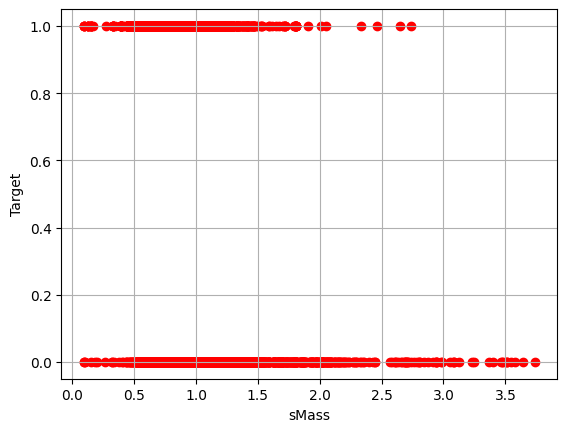

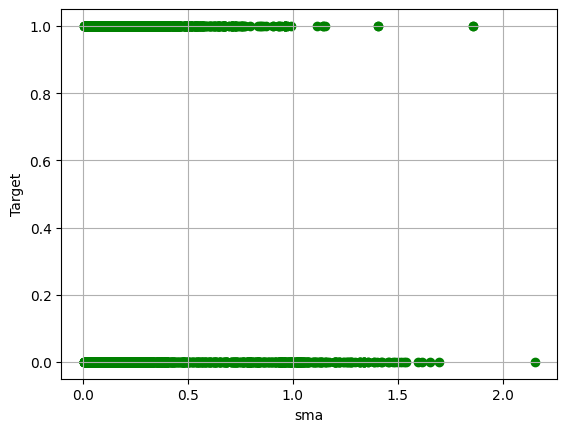

In [8]:
# ---- Some (unimportant) visualization ---- #

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(data["phys_smass"], data["Target"], color = 'red')

plt.xlabel("sMass")
plt.ylabel("Target")

plt.grid()
plt.show()

plt.figure()
plt.scatter(data["phys_sma"], data["Target"], color = "Green")

plt.xlabel("sma")
plt.ylabel("Target")

plt.grid()
plt.show()